# 🧬 Skip-Gram & Word2Vec — from one-hot symbols to vectors with meaning

> Unit 3 of the Philosophy of NLP course (LMU MCMP). Companion papers:
> Mikolov et al. (2013a, 2013b) — both PDFs in this folder.

So far the course has handled words as **discrete symbols**: an n-gram model
asks how often the bigram `("the", "king")` appears, and a hidden Markov model
shuffles between a small set of latent states. Both are symbolic systems —
no `(the, king)` is "near" any other pair; there is no geometry.

This notebook builds the first model in our course that gives meaning a
**geometry**: every word becomes a point in $\mathbb{R}^D$, and similar words
land near each other. The arc:

| Section | What |
|---|---|
| 0 | Setup — Colab detection, deps, run-mode flags |
| 1 | The skip-gram model — distributional hypothesis, architecture, loss, gradients |
| 2 | Toy implementation in pure NumPy |
| 3 | Why the toy can't scale — subsampling + negative sampling |
| 4 | Training on a real corpus (Brown + Reuters, ~2.3M tokens) |
| 5 | Inspecting the learned vectors — nearest neighbours, PCA |
| 6 | Pretrained GloVe and the classic analogy demo |
| 7 | What static embeddings still can't do — bridge to transformers |
| 8 | Cleanup |

The pedagogical pay-off lands in Section 6: we recover `king − man + woman ≈ queen` from pretrained vectors, then visualise the parallelogram geometry that makes it work.

## 0 — Setup

Detect Colab, install missing deps, set run-mode flags. This is the only
section that talks to the environment; everything below it is plain Python.

In [1]:
# ----------------------------------------------------------
# Setup — runs in Google Colab and locally without changes.
# ----------------------------------------------------------

# Detect Colab. The `google.colab` module is importable on Colab and
# nowhere else; we use that as our env flag.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"IN_COLAB = {IN_COLAB}")

# Install gensim if it's missing. Colab dropped gensim from its base image
# around 2023, and we need it for the pretrained-GloVe loader in Section 6.
# nltk, scikit-learn, numpy, matplotlib are pre-installed on Colab.
import importlib.util, subprocess, sys

if importlib.util.find_spec("gensim") is None:
    print("Installing gensim ...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gensim"], check=True)

# SSL workaround for macOS Python installs whose system certificate bundle is
# broken. Harmless on Colab. Lets `nltk.download(...)` and
# `gensim.downloader.load(...)` reach their CDNs without certificate errors.
import ssl
try:
    ssl._create_default_https_context = ssl._create_unverified_context
except AttributeError:
    pass

# ---- Run-mode flags ----
# SMOKE_TEST cuts the SGNS training down to a small slice of the corpus + 1
# epoch, so the whole notebook finishes in well under a minute. Flip to False
# for the real run (3-5 epochs on Brown + Reuters, ~5-8 min on CPU).
SMOKE_TEST      = False

# AUTO_DISCONNECT makes the very last cell disconnect the Colab runtime when
# the notebook finishes (to stop billing on Colab Pro). Off by default so a
# student iterating doesn't get kicked out mid-session.
AUTO_DISCONNECT = False

print(f"SMOKE_TEST      = {SMOKE_TEST}")
print(f"AUTO_DISCONNECT = {AUTO_DISCONNECT}")

IN_COLAB = False
SMOKE_TEST      = False
AUTO_DISCONNECT = False


## 1 — The skip-gram model

Three subsections cover the **philosophical commitment** behind the
architecture, the **forward-pass equations**, and the **loss + gradients**.
No code yet — we'll implement these in Sections 2 and 4.

### 1.1 — The distributional hypothesis

> *"You shall know a word by the company it keeps."* — J. R. Firth, 1957

The intuition behind every embedding model in this notebook is that **words
that appear in similar contexts tend to have similar meanings**. If we see
`bank` next to *interest*, *loan*, *account*, and `credit` next to those same
words, we should conclude that *bank* and *credit* are semantically related —
even though as strings they share nothing.

**Philosophical note.** This is a *use-theoretic* commitment about meaning:
meaning is something that emerges from co-occurrence patterns, not from
referential ties to mind-independent objects. The skip-gram architecture below
operationalises this exactly: each word is the vector that best predicts the
words it tends to appear with.

### 1.2 — Architecture and forward pass

Skip-gram is a **shallow neural network** that, given a *center* word, tries
to predict the **context** words inside a sliding window around it. The
embeddings we want are the **weights** of this network — training is just a
device to learn them.

**Matrix dimensions.**

- $V$: vocabulary size
- $D$: embedding dimension (a hyperparameter — typically 50–300)
- $x \in \mathbb{R}^V$: one-hot vector for the center word
- $W_1 \in \mathbb{R}^{V \times D}$: input-to-hidden weight matrix (one row per word — these are the *embeddings*)
- $W_2 \in \mathbb{R}^{D \times V}$: hidden-to-output matrix (one column per word — sometimes called the *context* matrix)

**Step 1 — hidden layer (embedding lookup).** Project the one-hot $x$ into embedding space:

$$
h = W_1^\top x \in \mathbb{R}^D
$$

Because $x$ is one-hot, this just *selects a row of $W_1$* — there is no real
matrix multiply happening at training time. The hidden layer **is** the embedding.

**Step 2 — output logits.** Score every word in the vocabulary as a potential context word:

$$
u = W_2^\top h \in \mathbb{R}^V
$$

**Step 3 — softmax.** Normalise to a distribution over context words:

$$
\hat y_i = \frac{\exp(u_i)}{\sum_{j=1}^{V} \exp(u_j)}
$$

**Interpretation.**

- $h$ **is** the embedding of the center word.
- $\hat y$ is the model's belief about which words live around it.
- $W_1$ ("input embeddings") and $W_2$ ("output embeddings") are *different
  vectors for the same word*. People usually take $W_1$ at the end of training
  as the actual word vector, but in negative-sampling training both matter.

### 1.3 — Cross-entropy loss and gradients

For a (center, context) training pair $(w_c, w_o)$, encode the truth $y$ as a
one-hot vector with a $1$ in slot $w_o$. The loss is **cross-entropy** between
$y$ and $\hat y$:

$$
\mathcal{L} \;=\; -\sum_{i=1}^{V} y_i \log \hat y_i \;=\; -\log \hat y_{w_o}
$$

A small bit of algebra shows the gradient w.r.t. the logits is just the
prediction error:

$$
e \;=\; \hat y - y \;\in\; \mathbb{R}^V
$$

From there, the gradients of $W_2$ and $W_1$ are outer products:

$$
\frac{\partial \mathcal{L}}{\partial W_2} = h \, e^\top
\qquad\qquad
\frac{\partial \mathcal{L}}{\partial W_1} = x \,(W_2 e)^\top
$$

and we update with SGD: $W \leftarrow W - \eta \,\partial \mathcal{L}/\partial W$.

**Training step recap.**

1. One-hot encode the center: $x$
2. $h = W_1^\top x$  *(embedding lookup)*
3. $u = W_2^\top h$  *(scores)*
4. $\hat y = \text{softmax}(u)$  *(probabilities)*
5. $\mathcal{L} = -\log \hat y_{\text{context}}$
6. Backprop: compute $e = \hat y - y$, then the outer-product gradients above
7. SGD update on $W_1$ and $W_2$

**The bottleneck.** The full softmax in step 4 normalises over the **entire
vocabulary** — that's $O(V)$ work per gradient step. For a real corpus with
$V \approx 50{,}000$ this is catastrophic. Section 3 fixes it with negative
sampling.

## 2 — Toy implementation in pure NumPy

Before scaling up, we implement the equations from §1 literally — one Python
loop per (center, context) pair, full softmax every step. On a 9-word corpus
this finishes instantly and lets us watch the equations execute. We'll throw
this code away in Section 4 and replace it with the production version.

In [2]:
# ----------------------------------------------------------
# Skip-Gram in pure NumPy — toy corpus, full softmax
# ----------------------------------------------------------
# Textbook implementation: every gradient step normalises over the whole
# vocabulary. Slow but transparent — useful for understanding what the
# equations *do* before we replace them with the negative-sampling trick.

import numpy as np
import re

def tokenize_corpus(text):
    # Lower-case, strip punctuation, split on whitespace.
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    return text.split()

def build_vocab(tokens):
    # Stable sorted set of unique tokens + index maps.
    vocab = sorted(set(tokens))
    word2idx = {w: i for i, w in enumerate(vocab)}
    idx2word = {i: w for w, i in word2idx.items()}
    return word2idx, idx2word

def generate_training_data(tokens, window_size=2):
    # (center, context) pairs as integer ids. Symmetric window.
    word2idx, _ = build_vocab(tokens)
    pairs = []
    for i, center in enumerate(tokens):
        lo = max(0, i - window_size)
        hi = min(len(tokens), i + window_size + 1)
        for j in range(lo, hi):
            if j != i:
                pairs.append((word2idx[center], word2idx[tokens[j]]))
    return pairs, word2idx


class SkipGramModel:
    # Full-softmax skip-gram. One Python loop per pair, one full softmax
    # per pair: fine for ~10 words, hopeless for a real corpus.

    def __init__(self, vocab_size, embedding_dim=10, learning_rate=0.01, seed=0):
        rng = np.random.default_rng(seed)
        self.V = vocab_size
        self.D = embedding_dim
        self.lr = learning_rate
        # Small random init so logits start near zero.
        self.W1 = rng.standard_normal((vocab_size, embedding_dim)) * 0.01
        self.W2 = rng.standard_normal((embedding_dim, vocab_size)) * 0.01

    @staticmethod
    def softmax(z):
        # Numerically stable: subtract max before exponentiating.
        e = np.exp(z - z.max())
        return e / e.sum()

    def forward(self, x):
        h = self.W1.T @ x        # (D,)  — embedding lookup
        u = self.W2.T @ h        # (V,)  — output logits
        return self.softmax(u), h

    def backprop(self, x, h, y_pred, y_true):
        e = y_pred - y_true                     # (V,) — prediction error
        dW2 = np.outer(h, e)                    # (D, V)
        dW1 = np.outer(x, self.W2 @ e)          # (V, D)
        self.W1 -= self.lr * dW1
        self.W2 -= self.lr * dW2

    def train(self, pairs, epochs=1000, print_every=200):
        for epoch in range(epochs):
            loss = 0.0
            for c_idx, o_idx in pairs:
                x = np.zeros(self.V); x[c_idx] = 1
                y_true = np.zeros(self.V); y_true[o_idx] = 1
                y_pred, h = self.forward(x)
                loss -= np.log(y_pred[o_idx] + 1e-9)
                self.backprop(x, h, y_pred, y_true)
            if epoch % print_every == 0:
                print(f"  epoch {epoch:4d}  loss={loss:.3f}")


# Demo on a 9-word corpus.
corpus = "the quick brown fox jumps over the lazy dog"
tokens = tokenize_corpus(corpus)
print("Tokens:", tokens)

pairs, word2idx = generate_training_data(tokens, window_size=2)
print(f"Generated {len(pairs)} (center, context) pairs")
print("First 6 pairs (as indices):", pairs[:6])

print("\nTraining the toy model (1000 epochs):")
toy_model = SkipGramModel(vocab_size=len(word2idx), embedding_dim=8, learning_rate=0.05, seed=0)
toy_model.train(pairs, epochs=1000, print_every=200)

# Each row of W1 is the embedding for the corresponding word.
print("\nEmbedding for 'fox':", np.round(toy_model.W1[word2idx['fox']], 3))
print("Embedding for 'dog':", np.round(toy_model.W1[word2idx['dog']], 3))

Tokens: ['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']
Generated 30 (center, context) pairs
First 6 pairs (as indices): [(7, 6), (7, 0), (6, 7), (6, 0), (6, 2), (0, 7)]

Training the toy model (1000 epochs):
  epoch    0  loss=62.383
  epoch  200  loss=46.578
  epoch  400  loss=46.643
  epoch  600  loss=46.650
  epoch  800  loss=46.643

Embedding for 'fox': [-0.422 -1.216 -0.346  0.059  0.468  0.677 -0.297 -1.224]
Embedding for 'dog': [ 0.719  1.122  0.153 -0.162 -1.989 -0.815  0.456  1.033]


## 3 — Why the toy can't scale: subsampling + negative sampling

The toy is correct but its outputs are not meaningful: with nine words there
is no statistical regularity to learn. To recover the distributional
hypothesis empirically we need (i) a real corpus, (ii) a way to handle
common words that drown the signal, and (iii) a loss that doesn't normalise
over the whole vocabulary on every step. The two non-trivial fixes are
**subsampling** and **negative sampling** — both from Mikolov 2013b.

### 3.1 — Subsampling of frequent words

Words like *the*, *of*, *a* dominate every context window without telling us
anything semantic. Word2Vec randomly **drops** each token $w$ with probability

$$
P_{\text{drop}}(w) \;=\; 1 - \sqrt{\frac{t}{f(w)}}
$$

where $f(w)$ is the empirical frequency and $t \approx 10^{-4}$ is a threshold.
*the*, *of*, *and* get aggressively thrown away; rare content words are kept
with probability 1. This both speeds up training and improves the quality of
the resulting embeddings (the model spends its capacity on informative pairs).

### 3.2 — Negative sampling — trading softmax for binary classification

Instead of asking *"out of the entire vocabulary, which word is the context?"*
(a hard $V$-way classification), we ask *"is this pair $(w_c, w_o)$ a real
co-occurrence, or did I make it up?"* — a single sigmoid output. For each
real positive pair we sample **$k$ negative pairs** by drawing context words
from a noise distribution $P_n$, and train a binary classifier.

The Word2Vec loss for one (center, context) pair becomes:

$$
\mathcal{L}_{\text{SGNS}}(w_c, w_o)
\;=\; -\log \sigma(\mathbf{v}_{w_o}^{\,\prime\top}\, \mathbf{v}_{w_c})
\;-\; \sum_{j=1}^{k} \mathbb{E}_{w_j \sim P_n}\!\big[\log \sigma(-\mathbf{v}_{w_j}^{\,\prime\top}\, \mathbf{v}_{w_c})\big]
$$

where $\sigma$ is the logistic sigmoid, $\mathbf{v}_w$ is the *input* embedding
(a row of $W_1$), and $\mathbf{v}_w^{\,\prime}$ is the *output* embedding (a row
of $W_2$). Read the two terms as:

- **Push together** the center vector and the true context's output vector.
- **Push apart** the center vector and each negative's output vector.

**The noise distribution.** Mikolov et al. found that drawing negatives from
the **unigram distribution raised to the 3/4 power** works best:

$$
P_n(w) \;\propto\; f(w)^{3/4}
$$

The exponent $3/4$ flattens the distribution slightly — frequent words still
get sampled often, but rare words get sampled more often than their raw
frequency would suggest. This gives the model more chances to push rare words
away from incorrect contexts.

Sections 4.1–4.4 implement all of this in NumPy. Mini-batched matrix operations
make it fast enough to train on a ~2.3M-token corpus in ~5 minutes on a laptop.

## 4 — Training on a real corpus (Brown + Reuters)

We combine two NLTK corpora — the **Brown** corpus (~1M tokens of edited
American English from the 1960s) and **Reuters** (~1.3M tokens of business /
financial news from 1987). Together they give us ~2.3M alphabetic tokens
spanning literary and news domains. Still tiny by Word2Vec standards (the
original paper used 6B+ tokens), but enough to see the distributional
hypothesis at work.

### 4.1 — Load and combine corpora

Brown is a general-purpose balanced corpus (fiction, news, religion, hobbies,
academic prose); Reuters is news. The combination keeps semantic relations
that overlap (people, places, time) and adds breadth where each is weak.

In [3]:
# ----------------------------------------------------------
# 4.1 Load Brown + Reuters and keep alphabetic tokens, lower-cased.
# ----------------------------------------------------------
# The SSL workaround in the Setup cell lets nltk.download() reach its CDN
# on macOS Python installs whose certificate bundle is broken.

import nltk
nltk.download('brown',   quiet=True)
nltk.download('reuters', quiet=True)
from nltk.corpus import brown, reuters

brown_tokens   = [w.lower() for w in brown.words()   if w.isalpha()]
reuters_tokens = [w.lower() for w in reuters.words() if w.isalpha()]
raw_tokens = brown_tokens + reuters_tokens

print(f"Brown alpha tokens   : {len(brown_tokens):,}")
print(f"Reuters alpha tokens : {len(reuters_tokens):,}")
print(f"Combined             : {len(raw_tokens):,}")

# Smoke-test mode: cap to a small slice so the rest of the notebook runs in
# seconds. Set SMOKE_TEST = False in the Setup cell for the real run.
if SMOKE_TEST:
    raw_tokens = raw_tokens[:100_000]
    print(f"SMOKE_TEST=True → capped to {len(raw_tokens):,} tokens.")

print(f"\nFirst 15 tokens: {raw_tokens[:15]}")
print(f"Tokens near Brown/Reuters seam (~{len(brown_tokens)}): "
      f"{raw_tokens[len(brown_tokens)-3:len(brown_tokens)+3]}")

Brown alpha tokens   : 981,716
Reuters alpha tokens : 1,327,141
Combined             : 2,308,857

First 15 tokens: ['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', 'recent', 'primary', 'election', 'produced', 'no']
Tokens near Brown/Reuters seam (~981716): ['dress', 'was', 'stupefying', 'asian', 'exporters', 'fear']


### 4.2 — Vocabulary, subsampling, negative-sampling table

We drop any word seen fewer than 10 times (most rare words add noise without
signal), compute the per-word keep-probability for subsampling, and pre-build
a 1M-entry array of negative samples drawn from $P_n(w) \propto f(w)^{0.75}$.
Each negative draw is then an O(1) lookup.

In [4]:
# ----------------------------------------------------------
# 4.2 Vocabulary, subsampling probabilities, negative-sampling table.
# ----------------------------------------------------------
import numpy as np
from collections import Counter

# ---- Training hyperparameters ----
# All in one place per NOTEBOOK_WRITING_SKILL §3 — tunable knobs at the top.
MIN_COUNT      = 10                       # drop words seen < 10 times
EMB_DIM        = 100                      # embedding dimension D
WINDOW         = 5                        # max context window radius
SUBSAMPLE_T    = 1e-4                     # Mikolov's subsampling threshold
NEG_K          = 5                        # negatives per positive pair
NEG_POWER      = 0.75                     # exponent on the noise distribution
NEG_TABLE_SIZE = 1_000_000                # precomputed neg-sampling table
LEARNING_RATE  = 0.025
BATCH_SIZE     = 1024
EPOCHS         = 1 if SMOKE_TEST else 5   # SMOKE_TEST keeps it under a minute
SEED           = 42

rng = np.random.default_rng(SEED)

# 1) Frequency-filtered vocabulary.
counts = Counter(raw_tokens)
vocab = [w for w, c in counts.most_common() if c >= MIN_COUNT]
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = vocab  # list doubles as idx → word
V = len(vocab)
print(f"Vocabulary size (min_count={MIN_COUNT}): V = {V:,}")
print("Top 10 by frequency:", [(w, counts[w]) for w in vocab[:10]])

# Sanity-check probe words: do they have enough occurrences to learn?
for w in ("king", "queen", "man", "woman", "money", "war", "love", "music"):
    print(f"  count({w!r}) = {counts.get(w, 0)}")

# 2) Filter the corpus to in-vocab token ids.
token_ids = np.array([word2idx[w] for w in raw_tokens if w in word2idx])
print(f"\nFiltered token count: {len(token_ids):,}")

# 3) Empirical frequencies over the filtered corpus.
freqs = np.bincount(token_ids, minlength=V).astype(np.float64)
freqs /= freqs.sum()

# 4) Mikolov subsampling — keep ≈ 1 for rare content, aggressive drop on stopwords.
keep_prob = np.minimum(1.0, np.sqrt(SUBSAMPLE_T / freqs))
print(f"\nSubsampling keep-probabilities:")
for w in ("the", "of", "and", "king", "queen", "philosophy"):
    if w in word2idx:
        print(f"  keep_prob({w!r}) = {keep_prob[word2idx[w]]:.4f}")

# 5) Negative-sampling distribution P_n(w) ∝ f(w)^{0.75}, pre-tabulated.
neg_probs = freqs ** NEG_POWER
neg_probs /= neg_probs.sum()
neg_table = rng.choice(V, size=NEG_TABLE_SIZE, p=neg_probs)
print(f"\nNegative-sampling table built ({NEG_TABLE_SIZE:,} entries).")

Vocabulary size (min_count=10): V = 12,127
Top 10 by frequency: [('the', 139248), ('of', 73191), ('to', 62558), ('and', 54501), ('in', 50590), ('a', 48298), ('said', 27344), ('for', 23271), ('it', 19864), ('mln', 18623)]
  count('king') = 124
  count('queen') = 47
  count('man') = 1246
  count('woman') = 224
  count('money') = 1283
  count('war') = 666
  count('love') = 240
  count('music') = 221

Filtered token count: 2,201,099

Subsampling keep-probabilities:
  keep_prob('the') = 0.0398
  keep_prob('of') = 0.0548
  keep_prob('and') = 0.0636
  keep_prob('king') = 1.0000
  keep_prob('queen') = 1.0000
  keep_prob('philosophy') = 1.0000

Negative-sampling table built (1,000,000 entries).


### 4.3 — Generate (center, context) training pairs

Word2Vec uses a **dynamic** window: for each center word it picks an actual
window size uniformly from $[1, \texttt{WINDOW}]$. This implicitly weights
nearby context words more (they appear in more dynamic windows than far ones).
Subsampling is applied here, before pair generation.

In [5]:
# ----------------------------------------------------------
# 4.3 Generate (center, context) pairs with dynamic window + subsampling.
# ----------------------------------------------------------
import time

def make_pairs(seq, window):
    # Drop tokens with probability 1 - keep_prob[id]; keeps content, dumps stopwords.
    keep_mask = rng.random(len(seq)) < keep_prob[seq]
    kept = seq[keep_mask]

    centers, contexts = [], []
    for i, c in enumerate(kept):
        w = rng.integers(1, window + 1)  # dynamic window
        lo, hi = max(0, i - w), min(len(kept), i + w + 1)
        for j in range(lo, hi):
            if j != i:
                centers.append(c)
                contexts.append(kept[j])
    return np.asarray(centers), np.asarray(contexts)


t0 = time.time()
centers, contexts = make_pairs(token_ids, WINDOW)
print(f"Generated {len(centers):,} training pairs in {time.time()-t0:.1f}s")
print(f"Example pairs (as words):")
for i in range(5):
    print(f"  ({idx2word[centers[i]]!r:>14}, {idx2word[contexts[i]]!r:<14})")

Generated 5,840,695 training pairs in 4.8s
Example pairs (as words):
  (      'fulton', 'county'      )
  (      'fulton', 'grand'       )
  (      'fulton', 'jury'        )
  (      'fulton', 'friday'      )
  (      'county', 'fulton'      )


### 4.4 — SGNS training loop

Pure NumPy, mini-batched. Each step is a stack of dot products + sigmoid +
scatter-add into the two embedding matrices — no autograd. With $V \approx
12{,}000$, $D = 100$, and ~5M pairs over 5 epochs, this finishes in a few
minutes on a laptop CPU.

In [6]:
# ----------------------------------------------------------
# 4.4 Skip-Gram with Negative Sampling — pure NumPy, mini-batched SGD.
# ----------------------------------------------------------
# Each step: gather B center + B*(1+K) context vectors, dot-product, sigmoid,
# scatter-add via np.add.at. No frameworks, no GPU, no autograd.

def sigmoid(x):
    # Clip the argument to avoid overflow in exp(-x) for very large positive x.
    return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))

# Initialise: input embeddings small & random, output embeddings at 0 —
# the trick from the original word2vec implementation.
W_in  = (rng.random((V, EMB_DIM)) - 0.5) / EMB_DIM
W_out = np.zeros((V, EMB_DIM))

n_pairs = len(centers)
print(f"Training SGNS: V={V}, D={EMB_DIM}, pairs={n_pairs:,}, "
      f"k={NEG_K}, batch={BATCH_SIZE}, epochs={EPOCHS}")

loss_history = []
t0 = time.time()
for epoch in range(EPOCHS):
    perm = rng.permutation(n_pairs)
    epoch_loss, n_batches = 0.0, 0

    for start in range(0, n_pairs, BATCH_SIZE):
        end = min(start + BATCH_SIZE, n_pairs)
        b_centers  = centers[perm[start:end]]
        b_contexts = contexts[perm[start:end]]
        B = len(b_centers)

        # Draw k negatives per positive — uniform indices into the precomputed
        # noise table (each entry is already distributed as f^0.75).
        neg_samples = neg_table[rng.integers(0, NEG_TABLE_SIZE, size=(B, NEG_K))]

        v_c   = W_in[b_centers]              # (B, D)
        v_pos = W_out[b_contexts]            # (B, D)
        v_neg = W_out[neg_samples]           # (B, K, D)

        s_pos = (v_c * v_pos).sum(axis=1)            # (B,)
        s_neg = np.einsum("bkd,bd->bk", v_neg, v_c)  # (B, K)

        # Loss for logging (mean over batch).
        pos_loss = -np.log(sigmoid(s_pos) + 1e-10)
        neg_loss = -np.log(sigmoid(-s_neg) + 1e-10).sum(axis=1)
        epoch_loss += (pos_loss + neg_loss).mean()
        n_batches  += 1

        # Gradients (from d/dx of log sigmoid).
        g_pos = sigmoid(s_pos) - 1.0   # (B,)
        g_neg = sigmoid(s_neg)         # (B, K)

        grad_v_c   = g_pos[:, None] * v_pos + np.einsum("bk,bkd->bd", g_neg, v_neg)
        grad_v_pos = g_pos[:, None] * v_c
        grad_v_neg = g_neg[:, :, None] * v_c[:, None, :]

        # Scatter-add into the global parameter matrices. np.add.at correctly
        # accumulates when the same index appears multiple times in a batch.
        np.add.at(W_in,  b_centers,                    -LEARNING_RATE * grad_v_c)
        np.add.at(W_out, b_contexts,                   -LEARNING_RATE * grad_v_pos)
        np.add.at(W_out, neg_samples.reshape(-1),
                  -LEARNING_RATE * grad_v_neg.reshape(-1, EMB_DIM))

    mean_loss = epoch_loss / n_batches
    loss_history.append(mean_loss)
    print(f"  epoch {epoch}: mean batch loss = {mean_loss:.4f}   "
          f"elapsed = {time.time()-t0:.1f}s")

print(f"\nTraining complete in {time.time()-t0:.1f}s.")

Training SGNS: V=12127, D=100, pairs=5,840,695, k=5, batch=1024, epochs=5
  epoch 0: mean batch loss = 2.6891   elapsed = 81.5s
  epoch 1: mean batch loss = 2.4350   elapsed = 164.0s
  epoch 2: mean batch loss = 2.3568   elapsed = 245.8s
  epoch 3: mean batch loss = 2.3038   elapsed = 328.1s
  epoch 4: mean batch loss = 2.2653   elapsed = 410.3s

Training complete in 410.3s.


### 4.5 — Loss curve sanity check

Should be monotonically decreasing. A flat line at epoch 0 usually means the
learning rate is too small; an exploding loss means the batch is too large or
the learning rate too high.

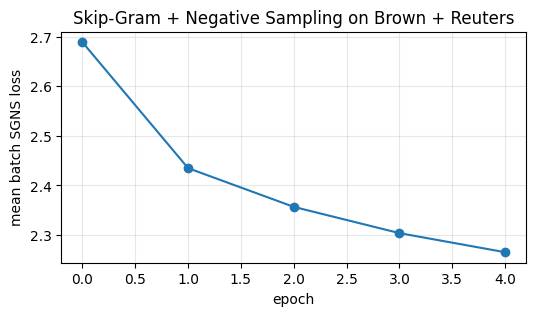

In [7]:
# 4.5 Loss curve.
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3))
plt.plot(loss_history, marker='o')
plt.xlabel("epoch")
plt.ylabel("mean batch SGNS loss")
plt.title("Skip-Gram + Negative Sampling on Brown + Reuters")
plt.grid(alpha=0.3)
plt.show()

## 5 — Inspecting the learned vectors

Two probes: **cosine nearest neighbours** (which words land near a query word?)
and a **2D PCA scatter** of hand-picked semantic groups (does the geometry
match our intuition?). A final markdown subsection sets honest expectations
about what 2.3M tokens *can't* do — motivating Section 6.

### 5.1 — Cosine nearest neighbours

In [8]:
# ----------------------------------------------------------
# 5.1 Cosine-similarity neighbourhoods over our learned embeddings.
# ----------------------------------------------------------
# We use W_in as the "word vector". (Some implementations average W_in + W_out;
# both are reasonable.) Pre-normalise once for fast cosine lookups.

W = W_in
W_norm = W / (np.linalg.norm(W, axis=1, keepdims=True) + 1e-10)

def nearest(word, k=8):
    if word not in word2idx:
        return f"{word!r} not in vocab"
    v = W_norm[word2idx[word]]
    sims = W_norm @ v
    top = np.argsort(-sims)[:k + 1]
    return [(idx2word[i], float(sims[i])) for i in top if idx2word[i] != word][:k]

for probe in ("king", "money", "war", "river", "love", "city", "music", "doctor",
              "company", "market", "oil"):
    nbrs = nearest(probe, 8)
    if isinstance(nbrs, str):
        print(nbrs); continue
    pretty = ", ".join(f"{w}({s:.2f})" for w, s in nbrs)
    print(f"  {probe:<8} → {pretty}")

  king     → burger(0.63), quiney(0.56), gorton(0.53), dumont(0.53), sturley(0.53), fahd(0.53), clergy(0.50), greville(0.50)
  money    → liquidity(0.69), resale(0.56), assistance(0.56), borrowing(0.56), category(0.55), shortage(0.54), tightness(0.54), drained(0.54)
  war      → hostilities(0.66), bombing(0.66), brink(0.64), confrontation(0.64), clash(0.64), pathet(0.62), aggression(0.62), offensive(0.61)
  river    → mississippi(0.70), tennessee(0.65), grove(0.64), buffalo(0.64), wyoming(0.64), garry(0.64), shores(0.63), smoky(0.63)
  love     → lover(0.78), admired(0.75), forever(0.74), hopeless(0.74), alas(0.74), loved(0.74), blessing(0.74), unto(0.74)
  city     → railroad(0.54), proclaim(0.54), superintendent(0.53), kansas(0.52), richmond(0.52), newark(0.52), showmanship(0.51), tennessee(0.51)
  music    → jazz(0.75), titled(0.72), musical(0.71), melody(0.71), lyrics(0.71), poetry(0.71), imitation(0.71), songs(0.71)
  doctor   → slept(0.73), meeker(0.71), visitor(0.71), grief(0.70

### 5.2 — PCA scatter of selected words

Pick four semantic groups (royalty, body parts, time, places) and project
their 100-dimensional vectors down to 2D with PCA. If our training has
captured anything meaningful, the four groups should cluster.

Plotting: ['king', 'queen', 'prince', 'lord', 'hand', 'eye', 'head', 'heart', 'day', 'night', 'year', 'morning', 'evening', 'city', 'town', 'country', 'world']


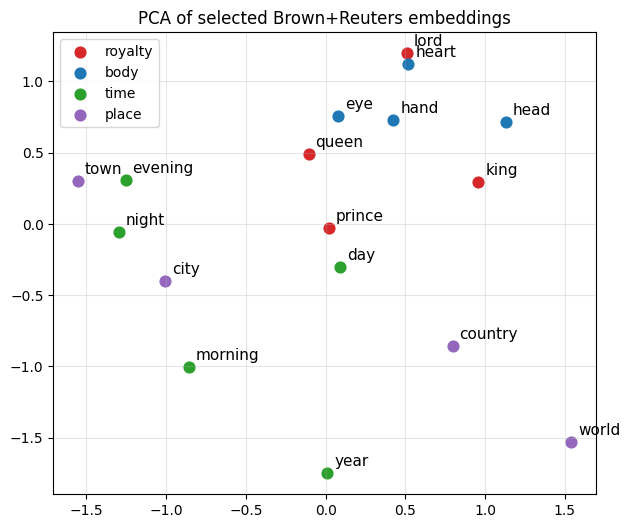

In [9]:
# ----------------------------------------------------------
# 5.2 PCA scatter of a few hand-picked words — does the geometry make sense?
# ----------------------------------------------------------
from sklearn.decomposition import PCA

groups = {
    "royalty": ["king", "queen", "prince", "lord"],
    "body":    ["hand", "eye", "head", "heart"],
    "time":    ["day", "night", "year", "morning", "evening"],
    "place":   ["city", "town", "country", "world"],
}
words = [w for ws in groups.values() for w in ws if w in word2idx]
print("Plotting:", words)
vecs = np.array([W[word2idx[w]] for w in words])

xy = PCA(n_components=2, random_state=0).fit_transform(vecs)

plt.figure(figsize=(7, 6))
colors = {"royalty": "tab:red", "body": "tab:blue",
          "time": "tab:green", "place": "tab:purple"}
for group, group_words in groups.items():
    pts = [xy[words.index(w)] for w in group_words if w in words]
    if not pts: continue
    xs, ys = zip(*pts)
    plt.scatter(xs, ys, color=colors[group], label=group, s=60)
    for x, y, w in zip(xs, ys, [w for w in group_words if w in words]):
        plt.annotate(w, (x, y), fontsize=11, xytext=(5, 5),
                     textcoords="offset points")
plt.title("PCA of selected Brown+Reuters embeddings")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 5.3 — Honest reckoning: what 2.3M tokens buys us

Look at the nearest-neighbour output above. Some queries land cleanly
(`market`, `company`, `oil` produce tight financial clusters from Reuters;
`war`, `city` get plausible semantic neighbours), others are noisy. With
only 2.3M tokens the model has seen *king* a few hundred times — not enough
to triangulate it tightly against *queen*, *prince*, *throne* in the analogy
sense.

What we *do* see is that the geometry is **non-random**: words from related
domains cluster, and the cluster boundaries roughly track the corpus seam
(Brown's literary cluster vs Reuters' financial cluster).

For the famous `king − man + woman ≈ queen` analogy to work cleanly, we need
vectors trained on **a much larger corpus**. Section 6 loads **GloVe**
(Pennington, Socher, Manning 2014), pretrained on **6 billion tokens** from
Wikipedia + Gigaword — roughly 2,500× our training data. GloVe uses a
slightly different objective (it factorises a log-co-occurrence matrix
rather than running a sliding window) but produces vectors of the same
flavour as Word2Vec.

## 6 — Pretrained GloVe and the classic analogy demo

This is the section that pays off the whole notebook. We load 6B-token-trained
GloVe vectors and show that the distributional hypothesis, applied at scale,
produces **vector arithmetic that respects semantics**:

$$\text{king} - \text{man} + \text{woman} \approx \text{queen}$$

Three subsections: load the vectors, run the analogies as text, then
**visualise the parallelogram geometry** that makes the arithmetic work.

### 6.1 — Loading GloVe

In [10]:
# ----------------------------------------------------------
# 6.1 Load pretrained GloVe (Wikipedia + Gigaword, 6B tokens, 100d).
# ----------------------------------------------------------
# gensim's downloader caches the file in ~/gensim-data/. Local laptops keep
# the cache between runs; Colab's filesystem is ephemeral, so each session
# re-downloads ~134 MB. SSL is already handled in the Setup cell.

import gensim.downloader as api
glove = api.load("glove-wiki-gigaword-100")
print(f"Loaded GloVe: {len(glove.key_to_index):,} words × {glove.vector_size} dims")

Loaded GloVe: 400,000 words × 100 dims


### 6.2 — Classic analogies (text)

`most_similar(positive=[A, B], negative=[C])` returns the words whose vectors
are closest by cosine to $A + B - C$. The famous case `king + woman − man`
should print *queen* as the top result — semantics literally falling out of
linear algebra.

In [11]:
# ----------------------------------------------------------
# 6.2 The wow demo: vector arithmetic on GloVe.
# ----------------------------------------------------------

def show_analogy(positive, negative, expected=None, k=5):
    plus  = " + ".join(positive)
    minus = " − " + " − ".join(negative) if negative else ""
    results = glove.most_similar(positive=positive, negative=negative, topn=k)
    head = f"{plus}{minus}".ljust(32)
    print(f"{head} → {[w for w, _ in results]}")
    if expected is not None:
        top = results[0][0]
        flag = "✅" if top == expected else "⚠️ "
        print(f"   {flag} top result: {top!r}   (expected {expected!r})")

print("=== Classic gender / royalty / capitals analogies ===\n")
show_analogy(["king", "woman"], ["man"], expected="queen")
show_analogy(["paris", "germany"], ["france"], expected="berlin")
show_analogy(["tokyo", "italy"], ["japan"], expected="rome")
show_analogy(["walking", "swim"], ["walk"], expected="swimming")
show_analogy(["bigger", "small"], ["big"], expected="smaller")
show_analogy(["uncle", "woman"], ["man"], expected="aunt")

print("\n=== Plain nearest neighbours in GloVe ===")
for probe in ("king", "music", "philosophy", "war", "bank"):
    print(f"  {probe:<11} → {[w for w, _ in glove.most_similar(probe, topn=8)]}")

=== Classic gender / royalty / capitals analogies ===

king + woman − man               → ['queen', 'monarch', 'throne', 'daughter', 'princess']
   ✅ top result: 'queen'   (expected 'queen')
paris + germany − france         → ['berlin', 'frankfurt', 'vienna', 'munich', 'hamburg']
   ✅ top result: 'berlin'   (expected 'berlin')
tokyo + italy − japan            → ['rome', 'milan', 'paris', 'naples', 'amsterdam']
   ✅ top result: 'rome'   (expected 'rome')
walking + swim − walk            → ['swimming', 'surfing', 'swam', 'rowing', 'jogging']
   ✅ top result: 'swimming'   (expected 'swimming')
bigger + small − big             → ['larger', 'smaller', 'large', 'tiny', 'size']
   ⚠️  top result: 'larger'   (expected 'smaller')
uncle + woman − man              → ['aunt', 'daughter', 'niece', 'grandmother', 'mother']
   ✅ top result: 'aunt'   (expected 'aunt')

=== Plain nearest neighbours in GloVe ===
  king        → ['prince', 'queen', 'son', 'brother', 'monarch', 'throne', 'kingdom', 'fathe

### 6.3 — Visualising the analogy geometry

The arithmetic isn't a coincidence. If we project the relevant words down to
2D, **analogous word pairs become roughly parallel vectors** — the
parallelogram structure that the original Mikolov paper illustrates.

Below we project two analogy families into 2D:

- **Left panel:** gendered word pairs (`man ↔ woman`, `king ↔ queen`,
  `brother ↔ sister`, `uncle ↔ aunt`, `actor ↔ actress`). All the arrows
  should point in roughly the same direction — that *is* the "gender axis".
- **Right panel:** country ↔ capital pairs
  (`france ↔ paris`, `germany ↔ berlin`, `italy ↔ rome`, `japan ↔ tokyo`,
  `spain ↔ madrid`). Same idea — a "is-the-capital-of" direction.

The text demo printed the answer; this picture shows *why* the arithmetic
works at all.

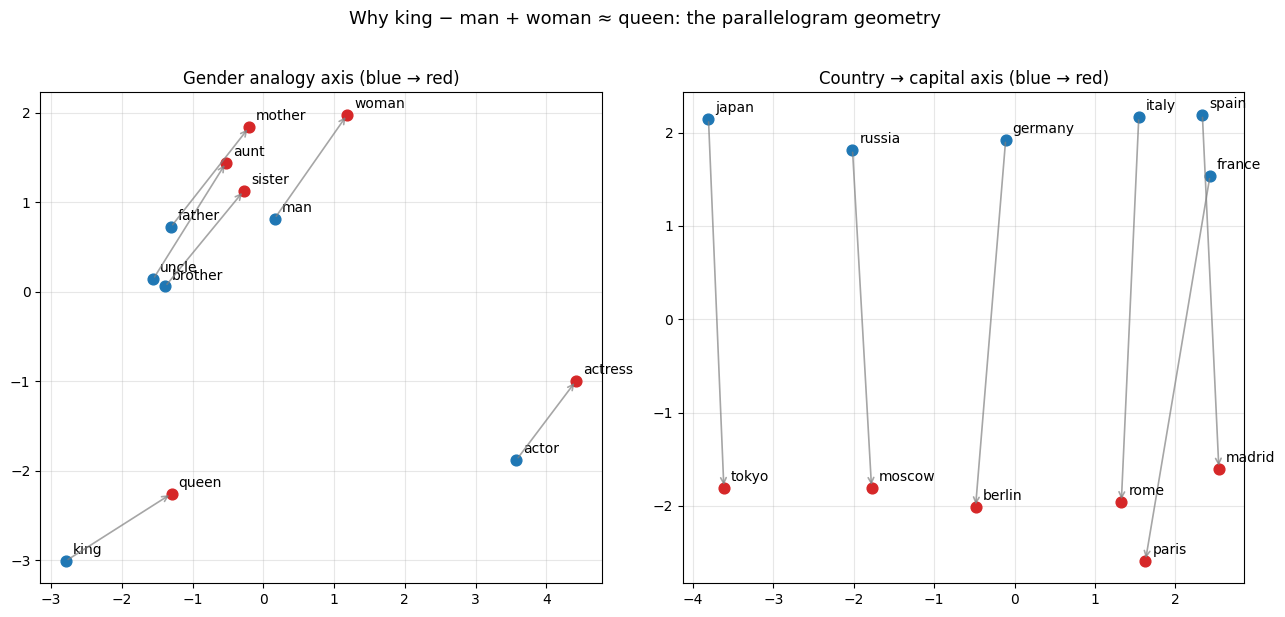

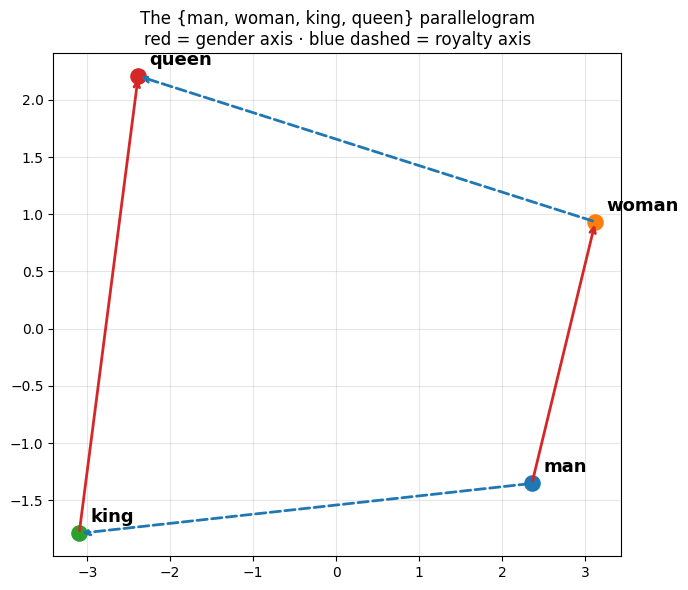

In [12]:
# ----------------------------------------------------------
# 6.3 Visualise the parallelogram geometry behind the analogies.
# ----------------------------------------------------------
# Project a handful of analogy pairs to 2D with PCA, then draw an arrow from
# each LHS to its RHS. Analogous pairs should produce roughly parallel arrows.

gender_pairs = [
    ("man",     "woman"),
    ("king",    "queen"),
    ("brother", "sister"),
    ("uncle",   "aunt"),
    ("actor",   "actress"),
    ("father",  "mother"),
]
capital_pairs = [
    ("france",  "paris"),
    ("germany", "berlin"),
    ("italy",   "rome"),
    ("japan",   "tokyo"),
    ("spain",   "madrid"),
    ("russia",  "moscow"),
]

def plot_analogy_panel(ax, pairs, title, left_color="tab:blue", right_color="tab:red"):
    words = [w for pair in pairs for w in pair]
    vecs  = np.array([glove[w] for w in words])
    xy    = PCA(n_components=2, random_state=0).fit_transform(vecs)
    coords = {w: xy[i] for i, w in enumerate(words)}

    for lhs, rhs in pairs:
        x0, y0 = coords[lhs]
        x1, y1 = coords[rhs]
        ax.scatter([x0], [y0], color=left_color,  s=60, zorder=3)
        ax.scatter([x1], [y1], color=right_color, s=60, zorder=3)
        ax.annotate(lhs, (x0, y0), fontsize=10, xytext=(5, 5),
                    textcoords="offset points")
        ax.annotate(rhs, (x1, y1), fontsize=10, xytext=(5, 5),
                    textcoords="offset points")
        ax.annotate(
            "",
            xy=(x1, y1), xytext=(x0, y0),
            arrowprops=dict(arrowstyle="->", color="gray", lw=1.2, alpha=0.7),
        )
    ax.set_title(title)
    ax.grid(alpha=0.3)

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13, 6))
plot_analogy_panel(ax_left,  gender_pairs,  "Gender analogy axis (blue → red)")
plot_analogy_panel(ax_right, capital_pairs, "Country → capital axis (blue → red)")
plt.suptitle("Why king − man + woman ≈ queen: the parallelogram geometry",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ---- The arithmetic itself, made visible: project {man, woman, king, queen}
# alone to 2D and draw the parallelogram. ----
quad = ["man", "woman", "king", "queen"]
quad_vecs = np.array([glove[w] for w in quad])
quad_xy = PCA(n_components=2, random_state=0).fit_transform(quad_vecs)
qm = dict(zip(quad, quad_xy))

fig, ax = plt.subplots(figsize=(7, 6))
for w, (x, y) in qm.items():
    ax.scatter([x], [y], s=120, zorder=3)
    ax.annotate(w, (x, y), fontsize=13, xytext=(8, 8),
                textcoords="offset points", fontweight="bold")

# Two analogous edges: man → woman and king → queen
for lhs, rhs in [("man", "woman"), ("king", "queen")]:
    (x0, y0), (x1, y1) = qm[lhs], qm[rhs]
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", color="tab:red", lw=2))

# Two "gender axis aligned" edges: man → king and woman → queen
for lhs, rhs in [("man", "king"), ("woman", "queen")]:
    (x0, y0), (x1, y1) = qm[lhs], qm[rhs]
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", color="tab:blue", lw=2,
                                linestyle="dashed"))

ax.set_title("The {man, woman, king, queen} parallelogram\n"
             "red = gender axis · blue dashed = royalty axis")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7 — What static embeddings still cannot do — the bank/bank problem

Look at the GloVe neighbours of **bank** from §6.2: they are entirely
*financial* (`banks, banking, credit, investment, lending, ...`). There is
no trace of the *river-bank* sense — even though in actual English usage
that meaning is common. Why?

A static embedding gives **one vector per word type**, no matter the context.
When *bank* appears in the corpus next to *river* and next to *deposit*,
both signals are averaged into a single representation. Because the financial
sense dominates Wikipedia + news text, that sense wins and the river sense is
squashed against it.

This is the fundamental limitation that motivates the next unit:

> 🧬 **Contextual embeddings** assign a *different* vector to a word for each
> sentence it appears in. *bank* in "I sat on the bank" gets a vector pulled
> toward `river`, `shore`, `grass`; *bank* in "I deposited it at the bank"
> gets pulled toward `credit`, `loan`, `account`. The same string, two
> different points in space.

The mechanism that lets you do this efficiently — **self-attention** — is the
subject of Unit 4. The vectors you trained here are the *inputs* to a
transformer; what the transformer does is rewrite each one based on the
others in the sequence.

### 📚 Going further

- 📝 **Mikolov et al. (2013a, 2013b)** — the two papers in this folder; source
  for the skip-gram / SGNS formulation we implemented in §§1–4.
- 📝 **Pennington, Socher, Manning (2014)** — *GloVe: Global Vectors for Word
  Representation* — the matrix-factorisation alternative we used in §6.
- 📝 **Peters et al. (2018)** — *ELMo*, the first widely-used contextual
  embeddings; the bridge into Unit 4.
- 📝 **Bolukbasi et al. (2016)** — *Man is to Computer Programmer as Woman is
  to Homemaker?* — a striking demonstration that the analogy structure picks
  up the corpus's biases as well as its semantics. Worth assigning before the
  next class.

## 8 — Cleanup

Optional Colab-specific cleanup. Only runs when both `AUTO_DISCONNECT` (set
in §0) and `IN_COLAB` are true.

In [13]:
# ----------------------------------------------------------
# 8 Optional: disconnect the Colab runtime (paid plans only).
# ----------------------------------------------------------
if AUTO_DISCONNECT and IN_COLAB:
    from IPython.display import Javascript, display
    print("AUTO_DISCONNECT=True — disconnecting Colab runtime.")
    display(Javascript("google.colab.kernel.disconnect()"))
else:
    print(f"AUTO_DISCONNECT={AUTO_DISCONNECT}, IN_COLAB={IN_COLAB} — staying connected.")

AUTO_DISCONNECT=False, IN_COLAB=False — staying connected.
